<a href="https://colab.research.google.com/github/miffylim2308/ADALL_github/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Step 1: Instantiate an OpenAI Client**

In [43]:
from google.colab import userdata
from openai import OpenAI

from datetime import datetime
from zoneinfo import ZoneInfo
# Singapore time
sg_time = datetime.now(ZoneInfo("Asia/Singapore"))

# Load key from Google Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key,
)
response = client.responses.create(
    model="gpt-5-mini",
    instructions="You are a data analyst expert who uses Python.",
    input="What is Exploratory Data Analysis?",
)
print(response.output_text)

Exploratory Data Analysis (EDA) is the process of summarizing, visualizing, and interrogating a dataset to understand its main characteristics, discover patterns, spot anomalies, test assumptions, and generate hypotheses before formal modeling. It’s an essential early step in any data science workflow.

Why it matters
- Reveals data quality issues (missing values, duplicates, inconsistencies).
- Helps choose appropriate models and preprocessing (transformations, encodings).
- Identifies relationships, trends, outliers, and useful features.
- Reduces risk of incorrect assumptions and model bias.

Typical EDA workflow (high level)
1. Clarify objectives and relevant variables.
2. Load data, inspect structure and types.
3. Clean data: handle missing values, duplicates, incorrect types.
4. Univariate analysis: distributions, summary statistics.
5. Bivariate/multivariate analysis: correlations, cross-tabs, conditional plots.
6. Outlier detection and treatment.
7. Feature relationships and in

In [ ]:
import pandas as pd
# Example: Replace this with the raw URL of your GitHub file
github_raw_url = 'https://raw.githubusercontent.com/miffylim2308/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'
try:
    df = pd.read_csv(github_raw_url)
    print("Successfully loaded data from GitHub!")
    display(df.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and the file format is compatible with `pd.read_csv`.")


Successfully loaded data from GitHub!


,Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
0,Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.80
1,Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
2,Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
3,Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
4,Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.30


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_Type      1000 non-null   object 
 6   Storage_GB        1000 non-null   int64  
 7   Touchscreen       1000 non-null   bool   
 8   Weight_kg         1000 non-null   float64
 9   Screen_Size_inch  1000 non-null   float64
 10  Discount_percent  1000 non-null   float64
 11  Price_SGD         1000 non-null   float64
 12  Brand_Discount    1000 non-null   int64  
 13  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 102.7+ KB


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
RAM_GB,1000.0,53.12800,44.413288,8.00,16.0000,32.000,64.0000,128.00
Storage_GB,1000.0,1505.02400,1380.203919,256.00,512.0000,1024.000,2048.0000,4096.00
Weight_kg,1000.0,2.03656,0.746477,1.00,1.3400,1.970,2.6800,3.50
Screen_Size_inch,1000.0,15.64570,1.759846,13.30,14.0000,15.600,17.3000,18.40
Discount_percent,1000.0,7.53823,4.334012,0.00,3.8150,7.480,11.2250,15.00
Price_SGD,1000.0,2277.79641,616.496246,995.77,1776.2125,2257.765,2711.6800,4156.50
Brand_Discount,1000.0,6.76800,2.634600,3.00,5.0000,7.000,10.0000,10.00
Member_Discount,1000.0,135.81066,41.344593,50.74,103.4350,131.095,163.0525,281.34


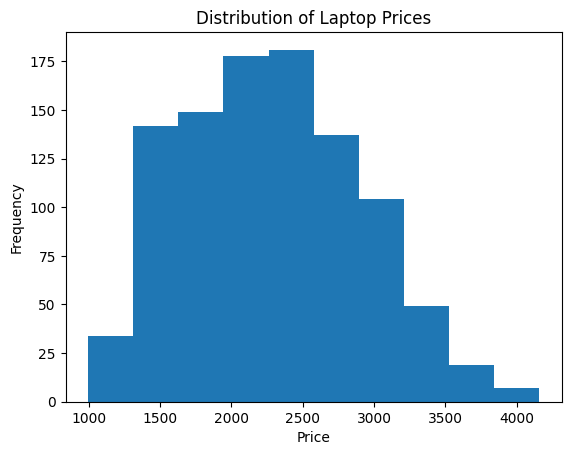

In [ ]:
#plot histogram
import matplotlib.pyplot as plt
plt.hist(df['Price_SGD'], bins=10)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Laptop Prices')
plt.show()



In [ ]:
# PROMPT FOR  DATA PROFILING #
prompt_eda = """
You are an experienced data analyst with Python. You are required data profiling tasks.
Using python/pandas/numpy/matplotlib/seaborn, generate code to:
1) show shape, data info, data types, first 5 rows of the dataset
2) list the columns
3) list Summary Statistics (include all to capture non-numeric summaries)
4) check any missing and duplicate values
5) show any notable distribution patterns (skewness, outliers)
Return only executable Python. Keep the code as simple as possible, concise and speific
this is the expected format in Pandas dataframe using read_csv, data shapes, columns types, summary stats
Dataset variable name: df
The CODE starts below:
"""
#print(prompt_eda)
response = client.responses.create(
    model="gpt-5-mini",
    instructions="You are a data analyst expert who uses Python.",
    input=prompt_eda,
)
print(response.output_text)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data (edit path as needed)
df = pd.read_csv('path_to_file.csv')

# 1) shape, info, dtypes, first 5 rows
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head(5))

# 2) list columns
print("\nColumns:\n", list(df.columns))

# 3) summary statistics (include all to capture non-numeric)
print("\nSummary statistics (all):\n", df.describe(include='all').T)

# 4) missing and duplicate values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("\nMissing values (count and %):\n", pd.concat([missing, missing_pct.rename('percent')], axis=1))
dupes = df.duplicated().sum()
print("\nDuplicate rows count:", dupes)
if dupes > 0:
    print("\nSample duplicate rows:\n", df[df.duplicated(keep=False)].head())

# 5) notable distribution patterns: skewness and outliers (IQR method)
numeric = df.select_dtypes(incl

Shape: (1000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Model             1000 non-null   object 
 2   CPU               1000 non-null   object 
 3   GPU               1000 non-null   object 
 4   RAM_GB            1000 non-null   int64  
 5   Storage_Type      1000 non-null   object 
 6   Storage_GB        1000 non-null   int64  
 7   Touchscreen       1000 non-null   bool   
 8   Weight_kg         1000 non-null   float64
 9   Screen_Size_inch  1000 non-null   float64
 10  Discount_percent  1000 non-null   float64
 11  Price_SGD         1000 non-null   float64
 12  Brand_Discount    1000 non-null   int64  
 13  Member_Discount   1000 non-null   float64
dtypes: bool(1), float64(5), int64(3), object(5)
memory usage: 102.7+ KB

Dtypes:
 Brand                object
Model 

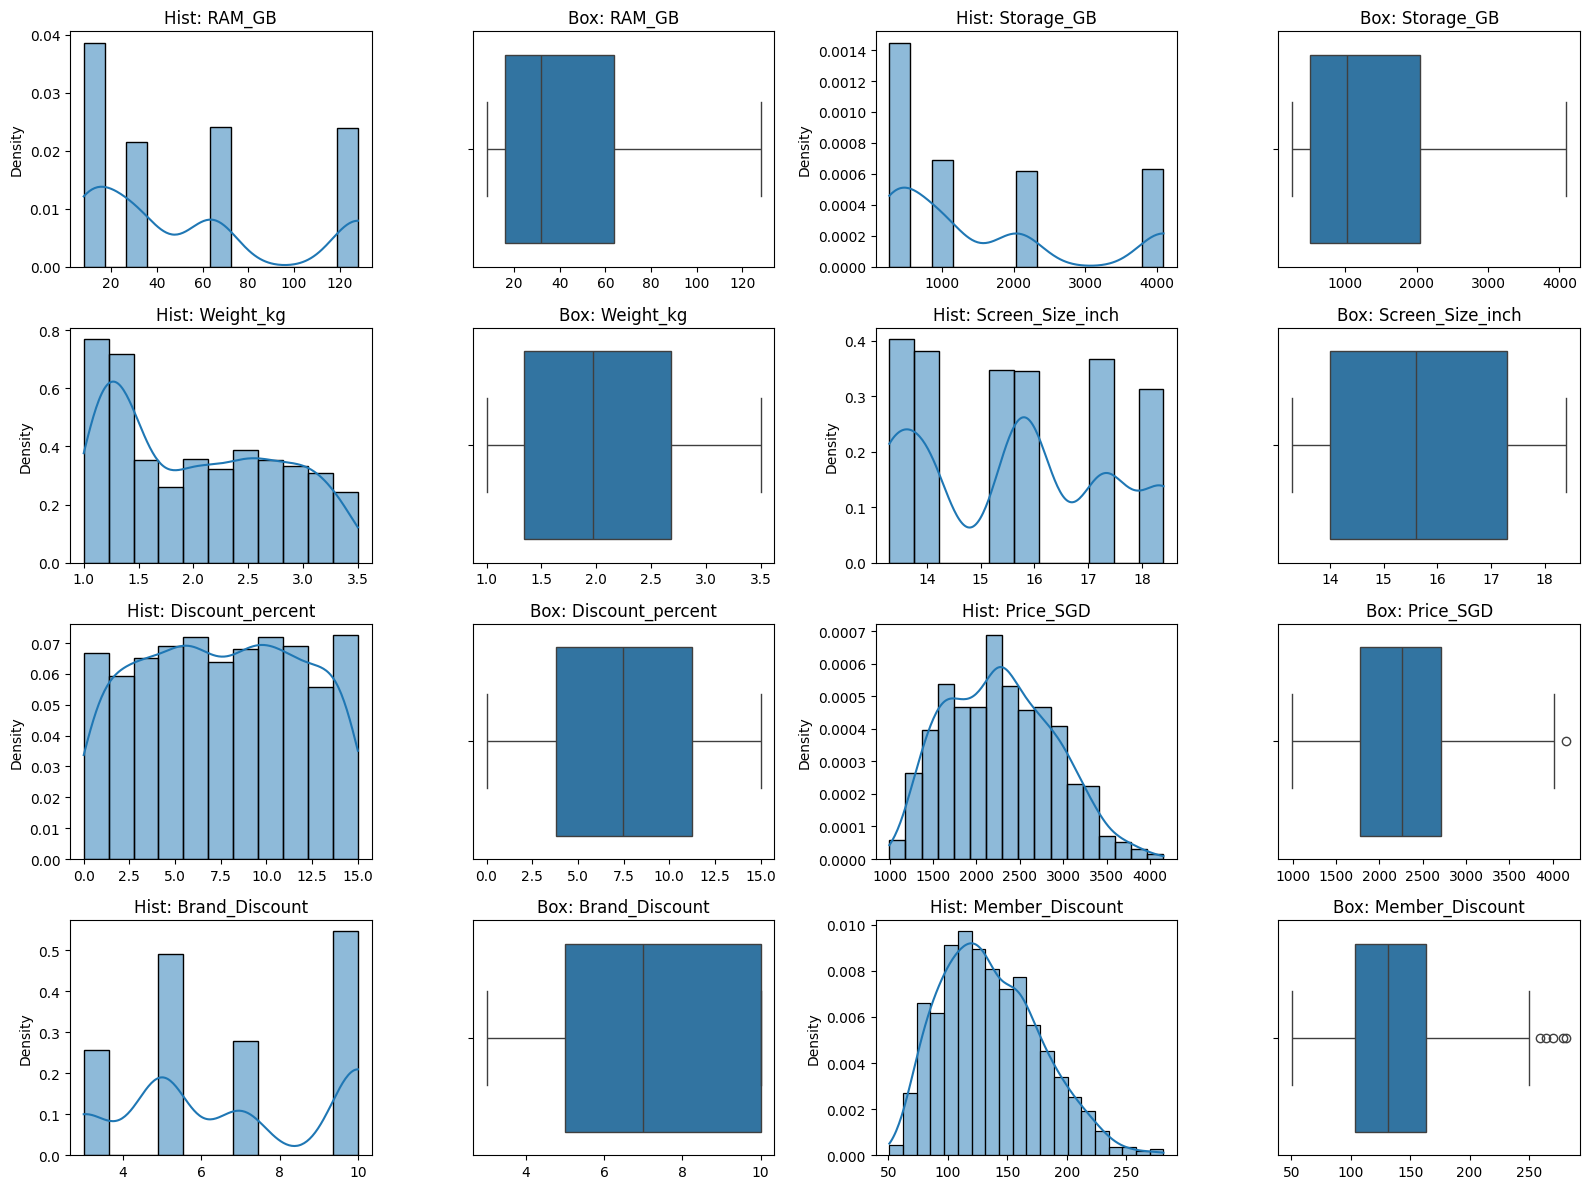

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) shape, info, dtypes, first 5 rows
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head(5))

# 2) list columns
print("\nColumns:\n", list(df.columns))

# 3) summary statistics (include all to capture non-numeric)
print("\nSummary statistics (all):\n", df.describe(include='all').T)

# 4) missing and duplicate values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("\nMissing values (count and %):\n", pd.concat([missing, missing_pct.rename('percent')], axis=1))
dupes = df.duplicated().sum()
print("\nDuplicate rows count:", dupes)
if dupes > 0:
    print("\nSample duplicate rows:\n", df[df.duplicated(keep=False)].head())

# 5) notable distribution patterns: skewness and outliers (IQR method)
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric) == 0:
    print("\nNo numeric columns for distribution analysis.")
else:
    skewness = df[numeric].skew().sort_values()
    print("\nSkewness (numeric columns):\n", skewness)
    highly_skewed = skewness[skewness.abs() > 1]
    print("\nHighly skewed columns (|skew|>1):\n", highly_skewed)

    outlier_stats = []
    for col in numeric:
        s = df[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out_count = s[(s < lower) | (s > upper)].shape[0]
        outlier_stats.append((col, q1, q3, iqr, lower, upper, out_count, round(out_count / len(df) * 100, 2)))
    outlier_df = pd.DataFrame(outlier_stats, columns=['col','q1','q3','iqr','lower','upper','outlier_count','outlier_percent']).set_index('col')
    print("\nOutlier summary (IQR method):\n", outlier_df.sort_values('outlier_count', ascending=False))

    # Plots: histograms with KDE and boxplots for numeric columns
    n = len(numeric)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4 * cols, 3 * rows * 2))
    for i, col in enumerate(numeric, start=1):
        plt.subplot(rows * 2, cols, 2 * (i - 1) + 1)
        sns.histplot(df[col].dropna(), kde=True, stat="density")
        plt.title(f"Hist: {col}")
        plt.xlabel('')
        plt.subplot(rows * 2, cols, 2 * (i - 1) + 2)
        sns.boxplot(x=df[col])
        plt.title(f"Box: {col}")
        plt.xlabel('')
    plt.tight_layout()
    plt.show()

In [37]:
data_preview=df.head(10).to_csv(index=False)
print(data_preview)

Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.8
Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.3
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4080,32,SSD,256,False,3.34,17.3,8.94,2224.12,5,155.69
Acer,TravelMate P6,Intel i9-14900HK,NVIDIA RTX 4080,128,SSD,1024,True,1.11,13.3,11.72,3016.36,5,211.15
Acer,Predator Helios 300,Intel Core Ultra 9 15700H,NVIDIA RTX 4070,16,SSD,2048,True,1.29,13.3,8.84,2579.29,5,180.55
Acer,Swift 3,Intel i5-14500H,NVIDIA

In [40]:
# Convert the first few rows to a string to send to OpenAI
data_preview = df.head(10).to_csv(index=False)
print(data_preview)

response = client.responses.create(
  model="gpt-5-mini",
  instructions=f"""You are an expert data scientist with extensive knowledge of predictive analysis and linear regression.""",
  input=f"Dataset:{data_preview}",
)
print(response.output_text)

Brand,Model,CPU,GPU,RAM_GB,Storage_Type,Storage_GB,Touchscreen,Weight_kg,Screen_Size_inch,Discount_percent,Price_SGD,Brand_Discount,Member_Discount
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4070,64,SSD,256,False,1.56,16.0,3.27,2413.36,5,144.8
Acer,Nitro 5,AMD Ryzen 9 8900HX,AMD Radeon 780M,32,SSD,1024,True,1.45,14.0,5.03,1773.75,5,124.16
Acer,Nitro 5,AMD Ryzen 5 8600H,NVIDIA RTX 4050,32,SSD,2048,False,1.34,14.0,4.41,1634.07,5,98.04
Acer,TravelMate P6,Intel Core Ultra 7 15500H,NVIDIA RTX 4060,16,SSD,4096,True,1.18,13.3,2.16,2362.59,5,118.13
Acer,Predator Helios 300,Intel i7-14800H,NVIDIA RTX 4070,8,SSD,1024,True,1.31,14.0,6.93,2218.55,5,155.3
Acer,Aspire 5,Intel i9-14900HK,NVIDIA RTX 4080,32,SSD,256,False,3.34,17.3,8.94,2224.12,5,155.69
Acer,TravelMate P6,Intel i9-14900HK,NVIDIA RTX 4080,128,SSD,1024,True,1.11,13.3,11.72,3016.36,5,211.15
Acer,Predator Helios 300,Intel Core Ultra 9 15700H,NVIDIA RTX 4070,16,SSD,2048,True,1.29,13.3,8.84,2579.29,5,180.55
Acer,Swift 3,Intel i5-14500H,NVIDIA

In [44]:
prompt = f"""
Laptop Specifications

Brand: {row['Brand']}
Model: {row['Model']}
CPU: {row['CPU']}
GPU: {row['GPU']}
RAM: {row['RAM_GB']} GB
Storage: {row['Storage_GB']} GB {row['Storage_Type']}
Touchscreen: {row['Touchscreen']}
Weight: {row['Weight_kg']} kg
Screen Size: {row['Screen_Size_inch']} inches
Discount: {row['Discount_percent']}%
Price: SGD {row['Price_SGD']}
Brand Discount: {row['Brand_Discount']}%
Member Discount: SGD {row['Member_Discount']}

Tasks:
1. Summarize the laptop.
2. Identify its strengths.
3. Recommend the target users.
4. Evaluate whether the selling price is reasonable.
"""

response = client.responses.create(
    model="gpt-5-mini",
    input=prompt
)

print(response.output_text)

1) Summary
- Acer Aspire 5, 16.0" (non‑touch), weight 1.56 kg.  
- Intel i9‑14900HK CPU, NVIDIA RTX 4070 GPU, 64 GB RAM, 256 GB SSD.  
- Listed price after discounts: SGD 2,413.36. Shown discounts: 3.27% + 5% brand + SGD 144.80 member. Implied original price ≈ SGD 2,795 and total savings ≈ SGD 381.64 (~13.6%).

2) Strengths
- Very strong CPU (i9‑14900HK) and a capable laptop GPU (RTX 4070) — excellent for CPU/GPU‑heavy tasks.  
- Large 64 GB of RAM — great for multitasking, VMs, large datasets, video editing.  
- Relatively light for a 16" powerful laptop (1.56 kg) — good portability for its performance class.  
- Price after discounts is competitive given the high‑end CPU/GPU/RAM combination.

3) Recommended target users
- Power users: developers running many VMs/containers, data scientists doing model development (not necessarily full training on huge datasets), and content creators who need fast editing and rendering.  
- Gamers who want high performance in a relatively portable 16"